# Experiment 2 — Does FinBERT strengthen the TSLA sentiment signal?

**Follow-up to experiment 1.** There, VADER gave a weak-but-significant *same-day*
correlation (Pearson r ≈ +0.12, p ≈ 0.004) and no predictive (next-day) signal.

**Hypothesis:** A finance-tuned model, **FinBERT** (`ProsusAI/finbert`), reads
financial headlines/bodies better than VADER's general lexicon and should
strengthen the correlation with TSLA returns.

**Setup for a fair comparison:** we reuse experiment 1's price data *and* its VADER
daily scores (`../experiment_1/tsla_daily_merged.csv`), re-score the same articles
with FinBERT (**headline + first 512 tokens of body**, averaged), and correlate both
methods against the *identical* returns — shown side by side.

In [1]:
# 1. Setup
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy import stats
from transformers import AutoTokenizer, AutoModelForSequenceClassification

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "experiment_2" else Path.cwd()
DATA_DIR = REPO_ROOT / "data" / "tsla"
EXP1_CSV = REPO_ROOT / "experiment_1" / "tsla_daily_merged.csv"

MODEL_NAME = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).eval()
device = "mps" if torch.backends.mps.is_available() else "cpu"
model.to(device)

lbl = {v.lower(): k for k, v in model.config.id2label.items()}
POS, NEG = lbl["positive"], lbl["negative"]
print("Device:", device, "| labels:", model.config.id2label)

/Users/georgia/Documents/Trading/sentimental_trading/trade_venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 32875.34it/s]

Device: mps | labels: {0: 'positive', 1: 'negative', 2: 'neutral'}


## 2. Load experiment 1 output (prices + VADER scores)
Its `date` column is our trading-day grid; `mean_sentiment` is VADER's daily score, renamed here to `vader_sentiment`.

In [2]:
# 2. Reuse experiment 1's aligned price + VADER table
base = pd.read_csv(EXP1_CSV, parse_dates=["date"])
base = base.rename(columns={"mean_sentiment": "vader_sentiment"})
base = base[["date", "c", "daily_return", "next_return", "vader_sentiment"]]
trading_days = base["date"].to_numpy()
print(f"{len(base)} trading days loaded from experiment 1")
base.head()

565 trading days loaded from experiment 1


,date,c,daily_return,next_return,vader_sentiment
0,2024-01-02,248.42,NaN,-0.040134,0.164387
1,2024-01-03,238.45,-0.040134,-0.002181,0.161350
2,2024-01-04,237.93,-0.002181,-0.001849,-0.007069
3,2024-01-05,237.49,-0.001849,0.012464,0.084625
4,2024-01-08,240.45,0.012464,-0.022832,0.086440


## 3. Re-parse & clean the articles (same logic as experiment 1)

In [3]:
# 3. Parse + clean (identical to experiment 1)
def parse_article(path):
    text = path.read_text(encoding="utf-8", errors="ignore")
    if not text.startswith("---"):
        return None
    parts = text.split("---", 2)
    if len(parts) < 3:
        return None
    fm, body = parts[1], parts[2]
    meta = {}
    for line in fm.strip().splitlines():
        if ":" in line:
            k, _, v = line.partition(":")
            meta[k.strip()] = v.strip().strip('"')
    if not meta.get("date"):
        return None
    return {"date": meta["date"], "title": meta.get("title", ""), "body": body}

PROMO_PAT = re.compile(r"Choose CNBC as your preferred source", re.I)
VIDEO_PAT = re.compile(r"^VIDEO\d")

def clean_body(body):
    text = re.sub(r"!\[[^\]]*\]\([^)]*\)", " ", body)
    text = re.sub(r"\[([^\]]*)\]\([^)]*\)", r"\1", text)
    keep = []
    for line in text.splitlines():
        s = line.strip()
        if not s:
            continue
        low = s.lower()
        if low in ("watch now", "in this article"):
            continue
        if VIDEO_PAT.match(s) or s.startswith("Stock Chart Icon"):
            continue
        if PROMO_PAT.search(s):
            continue
        s = re.sub(r"^#+\s*", "", s).strip("_ ")
        if s:
            keep.append(s)
    return " ".join(keep)

rows = []
for year in ["2024", "2025", "2026"]:
    for p in sorted((DATA_DIR / year).glob("*.md")):
        rec = parse_article(p)
        if rec:
            rows.append(rec)
news = pd.DataFrame(rows)
news["date"] = pd.to_datetime(news["date"]).dt.normalize()
news["clean_body"] = news["body"].apply(clean_body)
print(f"{len(news):,} articles parsed & cleaned")

4,770 articles parsed & cleaned


## 4. Score with FinBERT
Signed score = `p(positive) − p(negative)` ∈ [−1, 1]. Headline and (truncated) body scored separately, then averaged — mirroring experiment 1's headline+body structure.

In [4]:
# 4. Batched FinBERT scoring
@torch.no_grad()
def finbert_scores(texts, batch_size=32, max_length=512):
    out = []
    n = len(texts)
    for i in range(0, n, batch_size):
        batch = [t if isinstance(t, str) and t.strip() else "neutral" for t in texts[i:i + batch_size]]
        enc = tokenizer(batch, return_tensors="pt", truncation=True,
                        max_length=max_length, padding=True).to(device)
        probs = torch.softmax(model(**enc).logits, dim=-1)
        out.extend((probs[:, POS] - probs[:, NEG]).cpu().numpy().tolist())
        if (i // batch_size) % 25 == 0:
            print(f"  scored {min(i + batch_size, n):,}/{n:,}", end="\r")
    return out

print("Scoring headlines...")
news["headline_finbert"] = finbert_scores(news["title"].tolist())
print("\nScoring bodies (truncated to 512 tokens)...")
news["body_finbert"] = finbert_scores(news["clean_body"].tolist())
news["article_finbert"] = news[["headline_finbert", "body_finbert"]].mean(axis=1)
print("\nFinBERT score range:", round(news["article_finbert"].min(), 3),
      "to", round(news["article_finbert"].max(), 3))
news[["date", "title", "headline_finbert", "body_finbert", "article_finbert"]].head()

Scoring headlines...
  scored 4,032/4,770
Scoring bodies (truncated to 512 tokens)...
  scored 4,032/4,770
FinBERT score range: -0.967 to 0.936


,date,title,headline_finbert,body_finbert,article_finbert
0,2024-01-01,BYD beats Tesla for a second straight year aft...,0.906600,-0.026453,0.440073
1,2024-01-02,5 things to know before the stock market opens...,-0.011909,-0.830806,-0.421357
2,2024-01-02,"Apple, most valuable company in world and key ...",-0.909082,-0.941115,-0.925099
3,2024-01-02,CNBC Daily Open: 2023’s winners and losers,-0.107545,0.698495,0.295475
4,2024-01-02,CNBC Daily Open: A disappointing start to the ...,-0.937861,-0.964240,-0.951051


## 5. Aggregate to daily & align to trading days
Same rule as experiment 1: article-count-weighted daily mean, mapped to the first trading day on/after each news date, merged onto the price table.

In [5]:
# 5. Daily FinBERT sentiment -> trading day -> merge
daily = (news.groupby("date")
             .agg(finbert=("article_finbert", "mean"), count=("article_finbert", "size"))
             .reset_index())

def next_trading_day(d):
    idx = np.searchsorted(trading_days, np.datetime64(d), side="left")
    return pd.Timestamp(trading_days[idx]) if idx < len(trading_days) else pd.NaT

daily["trading_day"] = daily["date"].apply(next_trading_day)
tmp = daily.dropna(subset=["trading_day"]).copy()
tmp["w"] = tmp["finbert"] * tmp["count"]
agg = (tmp.groupby("trading_day")
          .agg(w=("w", "sum"), count=("count", "sum")).reset_index())
agg["finbert_sentiment"] = agg["w"] / agg["count"]
agg = agg.rename(columns={"trading_day": "date"})[["date", "finbert_sentiment", "count"]]

merged = base.merge(agg, on="date", how="inner").sort_values("date").reset_index(drop=True)
merged.to_csv("tsla_daily_finbert.csv", index=False)
print(f"{len(merged)} aligned trading days")
merged[["date", "c", "daily_return", "next_return", "vader_sentiment", "finbert_sentiment"]].head()

565 aligned trading days


,date,c,daily_return,next_return,vader_sentiment,finbert_sentiment
0,2024-01-02,248.42,NaN,-0.040134,0.164387,-0.223781
1,2024-01-03,238.45,-0.040134,-0.002181,0.161350,-0.015199
2,2024-01-04,237.93,-0.002181,-0.001849,-0.007069,-0.153485
3,2024-01-05,237.49,-0.001849,0.012464,0.084625,-0.086602
4,2024-01-08,240.45,0.012464,-0.022832,0.086440,-0.030544


## 6. Correlation comparison: VADER vs FinBERT

In [6]:
# 6. Correlations for both methods, both lags
def corr(x, y):
    m = x.notna() & y.notna()
    pr, pp = stats.pearsonr(x[m], y[m])
    sr, sp = stats.spearmanr(x[m], y[m])
    return int(m.sum()), pr, pp, sr, sp

rows = []
for method, col in [("VADER", "vader_sentiment"), ("FinBERT", "finbert_sentiment")]:
    for lag, ret in [("same-day (t)", "daily_return"), ("predictive (t+1)", "next_return")]:
        n, pr, pp, sr, sp = corr(merged[col], merged[ret])
        rows.append({"method": method, "lag": lag, "n": n,
                     "pearson_r": round(pr, 4), "pearson_p": round(pp, 4),
                     "spearman_r": round(sr, 4), "spearman_p": round(sp, 4)})
comparison = pd.DataFrame(rows)
comparison

,method,lag,n,pearson_r,pearson_p,spearman_r,spearman_p
0,VADER,same-day (t),564,0.1202,0.0042,0.1245,0.0031
1,VADER,predictive (t+1),564,-0.0244,0.5625,-0.0247,0.5588
2,FinBERT,same-day (t),564,0.2267,0.0000,0.2283,0.0000
3,FinBERT,predictive (t+1),564,-0.0348,0.4097,-0.0297,0.4815


## 7. Plots

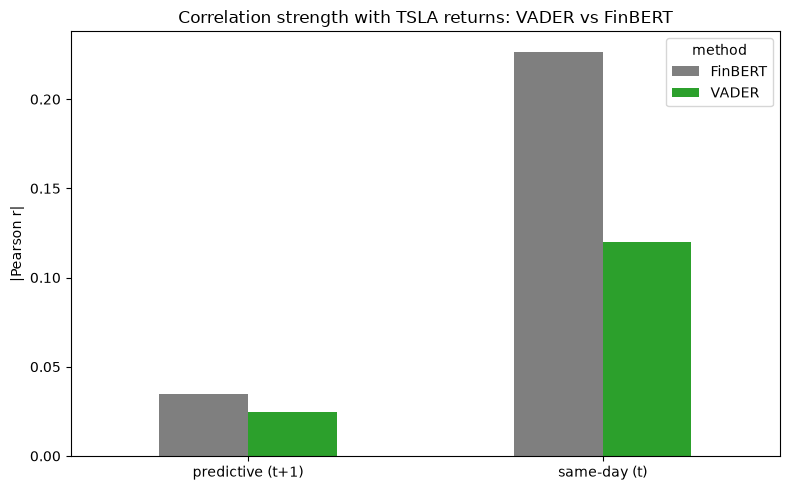

In [7]:
# 7a. |Pearson r| — VADER vs FinBERT by lag
piv = comparison.assign(abs_r=comparison["pearson_r"].abs()).pivot(
    index="lag", columns="method", values="abs_r")
ax = piv.plot(kind="bar", figsize=(8, 5), color=["tab:gray", "tab:green"])
ax.set_ylabel("|Pearson r|")
ax.set_title("Correlation strength with TSLA returns: VADER vs FinBERT")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

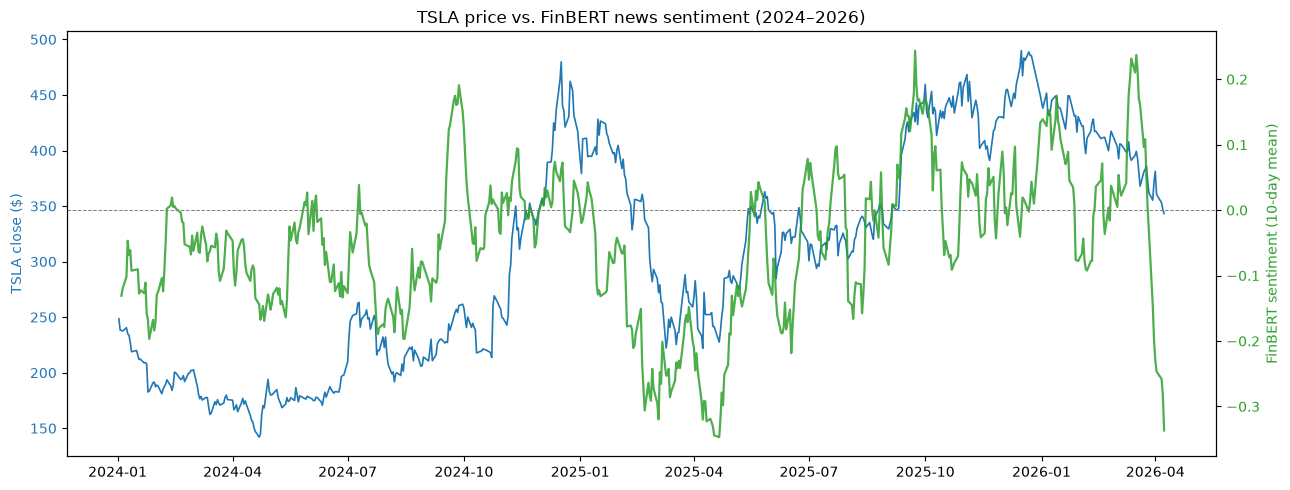

In [8]:
# 7b. TSLA price vs FinBERT rolling sentiment
fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(merged["date"], merged["c"], color="tab:blue", lw=1.2)
ax1.set_ylabel("TSLA close ($)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2 = ax1.twinx()
roll = merged.set_index("date")["finbert_sentiment"].rolling(10, min_periods=3).mean()
ax2.plot(roll.index, roll.values, color="tab:green", lw=1.6, alpha=0.85)
ax2.axhline(0, color="gray", ls="--", lw=0.7)
ax2.set_ylabel("FinBERT sentiment (10-day mean)", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")
ax1.set_title("TSLA price vs. FinBERT news sentiment (2024–2026)")
fig.tight_layout()
plt.show()

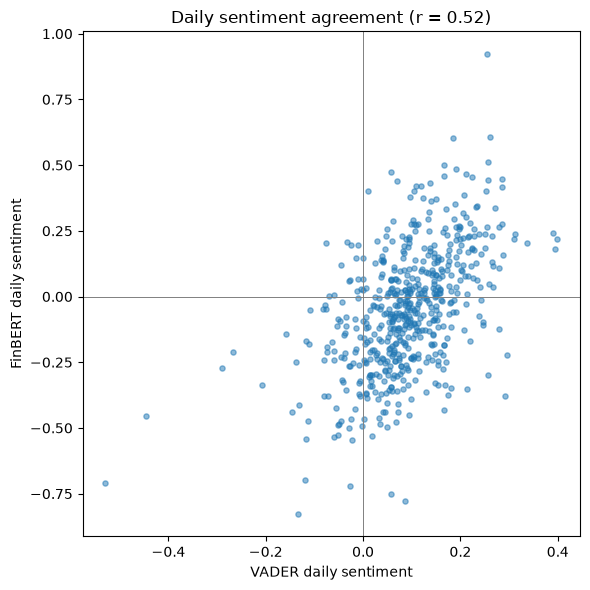

In [9]:
# 7c. Do VADER and FinBERT agree on daily sentiment?
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(merged["vader_sentiment"], merged["finbert_sentiment"], s=14, alpha=0.5)
r = merged[["vader_sentiment", "finbert_sentiment"]].corr().iloc[0, 1]
ax.axhline(0, color="gray", lw=0.7)
ax.axvline(0, color="gray", lw=0.7)
ax.set_xlabel("VADER daily sentiment")
ax.set_ylabel("FinBERT daily sentiment")
ax.set_title(f"Daily sentiment agreement (r = {r:.2f})")
plt.tight_layout()
plt.show()

## 8. Verdict — did FinBERT strengthen the signal?

In [10]:
# 8. Compare FinBERT vs VADER head to head
def get(method, lag):
    row = comparison[(comparison["method"] == method) & (comparison["lag"] == lag)].iloc[0]
    return row["pearson_r"], row["pearson_p"]

print("HYPOTHESIS: FinBERT strengthens the TSLA news-sentiment / return correlation")
print("=" * 74)
for lag in ["same-day (t)", "predictive (t+1)"]:
    vr, vp = get("VADER", lag)
    fr, fp = get("FinBERT", lag)
    print(f"\n{lag}:")
    print(f"   VADER  : r={vr:+.3f} (p={vp:.4f})")
    print(f"   FinBERT: r={fr:+.3f} (p={fp:.4f})")
    stronger = abs(fr) > abs(vr)
    print(f"   -> FinBERT |r| is {'HIGHER' if stronger else 'not higher'} "
          f"({abs(fr):.3f} vs {abs(vr):.3f})")

vr, vp = get("VADER", "same-day (t)")
fr, fp = get("FinBERT", "same-day (t)")
if abs(fr) > abs(vr) and fp < 0.05:
    verdict = "SUPPORTED — FinBERT gives a stronger, still-significant same-day signal"
elif fp < 0.05:
    verdict = "MIXED — FinBERT's same-day signal is significant but not stronger than VADER"
else:
    verdict = "NOT SUPPORTED — FinBERT did not strengthen the signal"
print("\n" + "=" * 74)
print("VERDICT:", verdict)
print("Saved -> tsla_daily_finbert.csv")

HYPOTHESIS: FinBERT strengthens the TSLA news-sentiment / return correlation

same-day (t):
   VADER  : r=+0.120 (p=0.0042)
   FinBERT: r=+0.227 (p=0.0000)
   -> FinBERT |r| is HIGHER (0.227 vs 0.120)

predictive (t+1):
   VADER  : r=-0.024 (p=0.5625)
   FinBERT: r=-0.035 (p=0.4097)
   -> FinBERT |r| is HIGHER (0.035 vs 0.024)

VERDICT: SUPPORTED — FinBERT gives a stronger, still-significant same-day signal
Saved -> tsla_daily_finbert.csv


### Interpreting this

- If FinBERT's **same-day |r|** clearly exceeds VADER's, the finance-tuned model is
  extracting more return-relevant signal from the same text.
- The **VADER-vs-FinBERT agreement** scatter (7c) shows how differently the two
  read the news — low agreement + higher FinBERT correlation is the strongest
  evidence that domain tuning matters here.
- A still-flat **predictive (t+1)** result for both would reinforce experiment 1's
  finding that same-day sentiment is largely a *reaction* to price, not a forecast.